# Preparation

In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/facial-keypoints-detection/training.zip
/kaggle/input/competitions/facial-keypoints-detection/SampleSubmission.csv
/kaggle/input/competitions/facial-keypoints-detection/IdLookupTable.csv
/kaggle/input/competitions/facial-keypoints-detection/test.zip


# Examine the data

In [16]:
import zipfile

# Open the ZIP file and extract the CSV file
with zipfile.ZipFile('/kaggle/input/competitions/facial-keypoints-detection/training.zip') as zip_ref:
    zip_ref.extractall('/kaggle/working/')

# Load the CSV file and display the first five rows
train_df = pd.read_csv('/kaggle/working/training.csv')
train_df.head()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,238 236 237 238 240 240 239 241 241 243 240 23...
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170,219 215 204 196 204 211 212 200 180 168 178 19...
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368,144 142 159 180 188 188 184 180 167 132 84 59 ...
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383,193 192 193 194 194 194 193 192 168 111 50 12 ...
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166,147 148 160 196 215 214 216 217 219 220 206 18...


# Image format conversion

In [17]:
# 1st step: Convert image strings to numpy arrays
train_df['Image'] = train_df['Image'].apply(lambda img: np.fromstring(img, sep=' ') if isinstance(img, str) else np.nan)

# 2nd step: Remove rows with missing data; in order to clean unwanted inputs
train_df.dropna(inplace=True)

# 3rd step: Convert image column to 96x96 pixels array
X = np.stack(train_df['Image'].values)
X = X.reshape(-1, 96, 96, 1).astype(np.float32)

# 4th step: Normalize pixel values
X /= 255.0

# 5th step: Extract target keypoints
y = train_df.drop('Image', axis=1).values

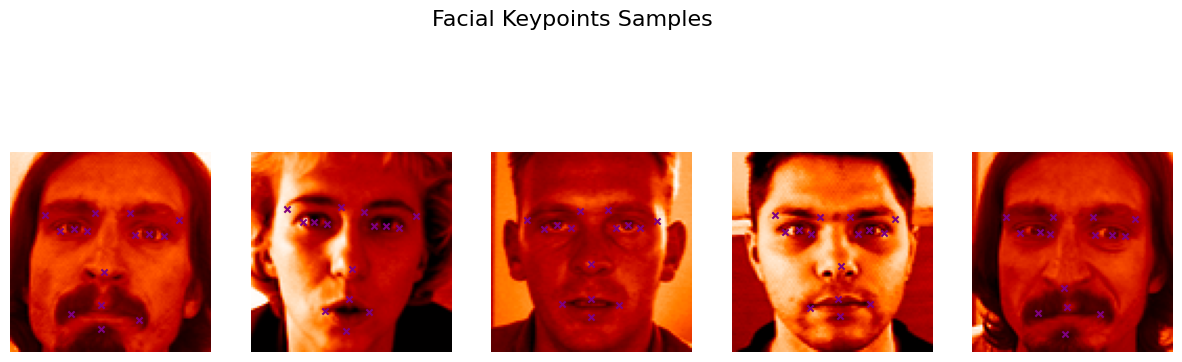

In [18]:
import matplotlib.pyplot as plt

# Function to plot an image with keypoints
def plot_image_with_keypoints(image, keypoints):
    plt.imshow(image.reshape(96, 96), cmap='gist_heat')
    plt.scatter(keypoints[0::2], keypoints[1::2], marker='x', s=20, color='purple')
    plt.axis('off')

# Plot 5 randomly-generated images
plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plot_image_with_keypoints(X[i], y[i])
plt.suptitle('Facial Keypoints Samples', fontsize=16)
plt.show()

# Convolutional Neural Network

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Convolutional Neural Network (CNN) model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(96, 96, 1)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(30)
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

# Display the model's summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 94, 94, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │        15,390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,662,174 (25.41 MB)

 Trainable params: 6,662,174 (25.41 MB)

 Non-trainable params: 0 (0.00 B)

# Model training

In [20]:
# Train the model
history = model.fit(
    X, y,
    epochs=50,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 574ms/step - loss: 1259.3307 - mae: 28.6680 - val_loss: 112.2600 - val_mae: 8.4306
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 576ms/step - loss: 147.7785 - mae: 9.4380 - val_loss: 27.8142 - val_mae: 3.9747
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 579ms/step - loss: 52.8656 - mae: 5.7174 - val_loss: 20.7769 - val_mae: 3.4339
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 599ms/step - loss: 42.0510 - mae: 5.1216 - val_loss: 18.9374 - val_mae: 3.2825
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 578ms/step - loss: 37.8941 - mae: 4.8487 - val_loss: 24.9772 - val_mae: 3.8355
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 578ms/step - loss: 35.9044 - mae: 4.6916 - val_loss: 20.0072 - val_mae: 3.3822
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 576ms/step - loss: 31.9885 - mae: 4.4466 - val_loss: 21.1603 - val_mae: 3.5388
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 580ms/step - loss: 27.6662 - mae: 4.1228 - val_loss: 16.6856 - val_mae: 3.0990
Epoch 9/50
31/31 ━━━━━━━━━━

# Generate predictions

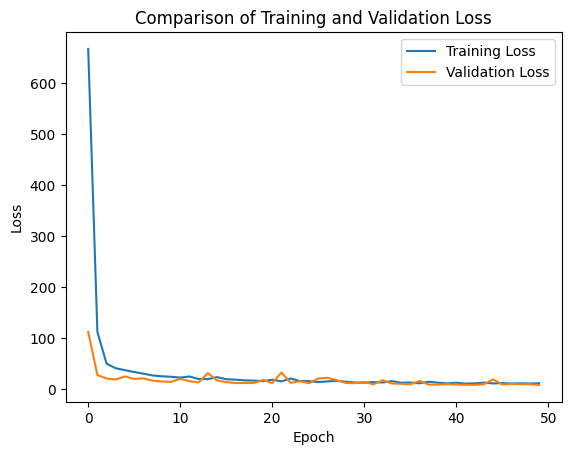

In [21]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Comparison of Training and Validation Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


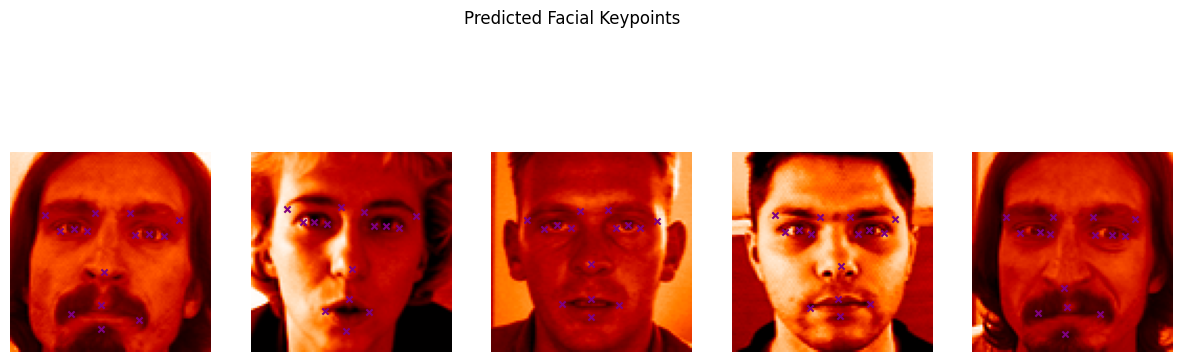

In [22]:
preds = model.predict(X[:5])

plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plot_image_with_keypoints(X[i], y[i])
plt.suptitle('Predicted Facial Keypoints')
plt.show()

# Submission

In [23]:
# Create a new model file
model.save('/kaggle/working/facial_keypoints_model.h5')

In [24]:
# Save the existing first five lookups
lookup_df = pd.read_csv('/kaggle/input/competitions/facial-keypoints-detection/IdLookupTable.csv')

In [25]:
test_df = pd.read_csv('/kaggle/input/competitions/facial-keypoints-detection/test.zip')
test_df['Image'] = test_df['Image'].apply(lambda im: np.fromstring(im, sep=' ').reshape(96, 96) / 255.0)

X_test = np.stack(test_df['Image'].values).reshape(-1, 96, 96, 1)

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/kaggle/working/facial_keypoints_model.h5')
preds = model.predict(X_test)

In [32]:
preds *= 96

In [33]:
lookup_df = pd.read_csv('/kaggle/input/competitions/facial-keypoints-detection/IdLookupTable.csv')
lookup_df.head()

,RowId,ImageId,FeatureName,Location
0,1,1,left_eye_center_x,NaN
1,2,1,left_eye_center_y,NaN
2,3,1,right_eye_center_x,NaN
3,4,1,right_eye_center_y,NaN
4,5,1,left_eye_inner_corner_x,NaN


In [34]:
# Load the features from the training data
features = pd.read_csv('/kaggle/input/competitions/facial-keypoints-detection/training.zip').dropna().columns[:-1]

# Create a dictionary for each test data
pred_df = pd.DataFrame(preds, columns=features)

# Create a submission file
locations = []
for idx, row in lookup_df.iterrows():
    feature_name = row['FeatureName']
    image_id = row['ImageId'] - 1
    value = pred_df.loc[image_id, feature_name]
    locations.append(value)

lookup_df['Location'] = locations

In [35]:
lookup_df.drop(['ImageId', 'FeatureName'], axis=1, inplace=True)

In [38]:
lookup_df.to_csv('submission.csv', index=False)

print("Successfully saved as CSV file.")

Successfully saved as CSV file.
